In [97]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2 as cv

In [98]:
def pastikan_uint8(citra):
    """
    Mengubah citra ke format uint8 rentang 0-255.

    Kenapa perlu?
    - Beberapa fungsi membaca gambar sebagai float 0-1.
    - Fungsi histogram manual lebih aman jika nilai piksel berupa integer 0-255.
    """
    citra = np.array(citra)

    if citra.dtype == np.uint8:
        return citra

    if citra.max() <= 1.0:
        citra = citra * 255

    return np.clip(citra, 0, 255).astype(np.uint8)


def baca_grayscale(path):
    """
    Membaca citra dari path dan mengubahnya menjadi grayscale.

    Parameter:
    - path: lokasi file gambar, contoh: "Assets/soal1.png"

    Return:
    - citra grayscale bertipe uint8
    """
    citra = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if citra is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    return pastikan_uint8(citra)


def baca_rgb(path):
    """
    Membaca citra berwarna dan mengubah format BGR OpenCV menjadi RGB Matplotlib.
    """
    citra_bgr = cv.imread(path, cv.IMREAD_COLOR)

    if citra_bgr is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    citra_rgb = cv.cvtColor(citra_bgr, cv.COLOR_BGR2RGB)
    return pastikan_uint8(citra_rgb)


def tampilkan_citra(citra, judul="Citra", cmap="gray", figsize=(8, 5)):
    """
    Menampilkan satu citra.
    """
    plt.figure(figsize=figsize)

    if len(citra.shape) == 2:
        plt.imshow(citra, cmap=cmap)
    else:
        plt.imshow(citra)

    plt.title(judul)
    plt.show()


def tampilkan_beberapa(daftar_citra, daftar_judul=None, cmap="gray", figsize=(14, 5)):
    """
    Menampilkan beberapa citra dalam satu baris.
    """
    jumlah = len(daftar_citra)

    if daftar_judul is None:
        daftar_judul = [f"Citra {i+1}" for i in range(jumlah)]

    plt.figure(figsize=figsize)

    for i, citra in enumerate(daftar_citra):
        plt.subplot(1, jumlah, i + 1)

        if len(citra.shape) == 2:
            plt.imshow(citra, cmap=cmap)
        else:
            plt.imshow(citra)

        plt.title(daftar_judul[i])

    plt.tight_layout()
    plt.show()


Tinggi gambar: 720
Lebar gambar: 720


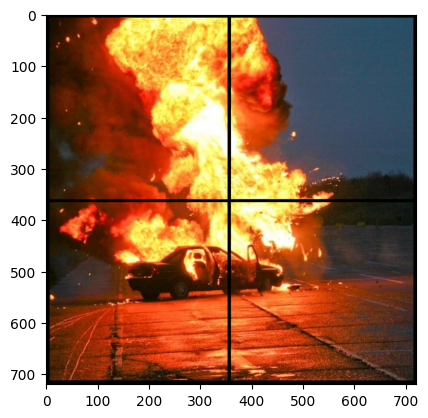

In [99]:
mobilAsli = plt.imread('Assets/Meledak.png')
mobilAbu = baca_grayscale('Assets/Meledak.png')

plt.imshow(mobilAsli)
tinggi, lebar = mobilAbu.shape
print("Tinggi gambar:", tinggi)
print("Lebar gambar:",lebar)

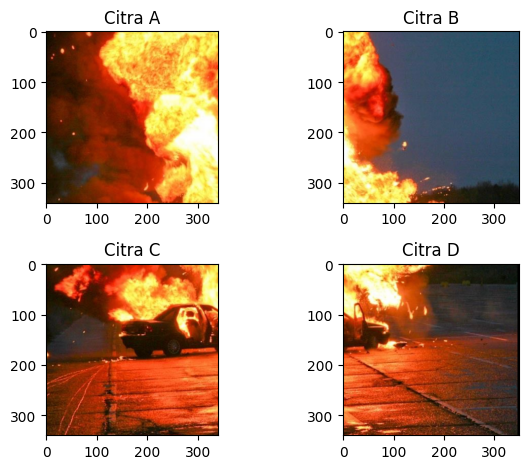

In [100]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

mobA = slice(mobilAsli, 10, 350, mode='H')
mobilA = slice(mobA, 10, 350, mode='V')

mobB = slice(mobilAsli, 10, 350, mode='H')
mobilB = slice(mobB, 360, 710, mode='V')

mobC = slice(mobilAsli, 370, 710, mode='H')
mobilC = slice(mobC, 10, 350, mode='V')

mobD = slice(mobilAsli, 370, 710, mode='H')
mobilD = slice(mobD, 370, 720, mode='V')

plt.subplot (2,2,1) 
plt.imshow(mobilA)
plt.title('Citra A')    

plt.subplot (2,2,2)
plt.imshow(mobilB)
plt.title('Citra B')

plt.subplot (2,2,3)
plt.imshow(mobilC)
plt.title('Citra C')

plt.subplot (2,2,4)
plt.imshow(mobilD)
plt.title('Citra D')

plt.tight_layout()


In [101]:
def merge(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan 

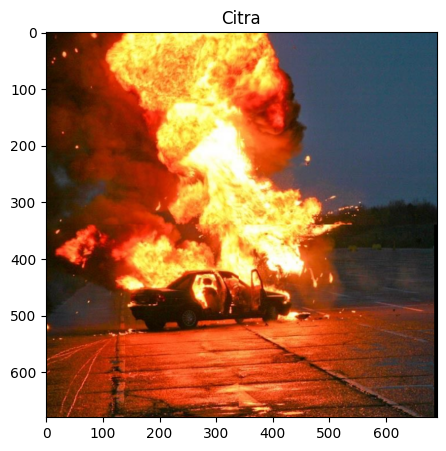

In [102]:
mergeAtas = merge(mobilA, mobilB, "H")
mergeBawah = merge(mobilC, mobilD, "H")
mergeAll = merge(mergeAtas, mergeBawah, "V")

tampilkan_citra(mergeAll)

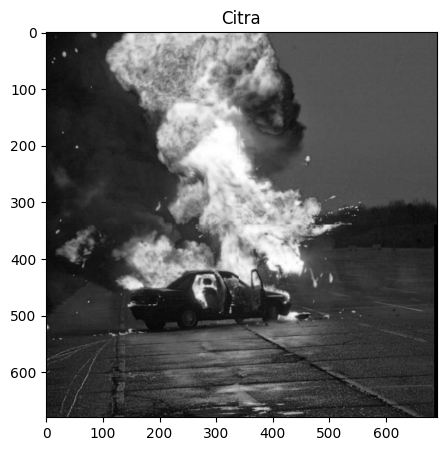

In [103]:
mobilGray = cv.cvtColor(mergeAll, cv.COLOR_BGR2GRAY)
tampilkan_citra(mobilGray)

In [104]:
def buat_hist(citra, normalisasi=False):
    """
    Membuat histogram manual untuk citra grayscale.

    Parameter:
    - citra: citra grayscale 2D
    - normalisasi:
      False -> histogram berisi jumlah piksel
      True  -> histogram berisi proporsi piksel

    Return:
    - histogram array panjang 256
    """
    citra = pastikan_uint8(citra)

    if len(citra.shape) != 2:
        raise ValueError("buat_hist hanya menerima citra grayscale 2D.")

    tinggi, lebar = citra.shape
    hist = np.zeros(256, dtype=float)

    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(citra[i, j])
            hist[nilai] += 1

    if normalisasi:
        total_piksel = tinggi * lebar
        hist = hist / total_piksel

    return hist


def plot_histogram(hist, judul="Histogram", warna="red", figsize=(10, 4)):
    """
    Menampilkan histogram.
    """
    plt.figure(figsize=figsize)
    plt.bar(range(256), hist, color=warna, width=0.8)
    plt.title(judul)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel" if np.max(hist) > 1 else "Proporsi Piksel")
    plt.xlim([0, 255])
    plt.show()


def bandingkan_histogram(citra1, citra2, judul1="Sebelum", judul2="Sesudah"):
    """
    Membandingkan histogram dua citra.
    Cocok untuk melihat efek ekualisasi atau spesifikasi.
    """
    hist1 = buat_hist(citra1)
    hist2 = buat_hist(citra2)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.bar(range(256), hist1, color="green", width=0.8)
    plt.title(judul1)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.subplot(1, 2, 2)
    plt.bar(range(256), hist2, color="red", width=0.8)
    plt.title(judul2)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.tight_layout()
    plt.show()


In [105]:
def hitung_cdf(citra):
    hist = buat_hist(citra, normalisasi=False)
    cdf = np.zeros(256, dtype=float)

    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    return hist, cdf

def ekualisasi(citra):
    citra = pastikan_uint8(citra)

    if len(citra.shape) != 2:
        raise ValueError("ekualisasi hanya menerima citra grayscale 2D.")

    tinggi, lebar = citra.shape
    total_piksel = tinggi * lebar

    hist, cdf = hitung_cdf(citra)

    cdf_normal = np.round((cdf * 255) / total_piksel).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            nilai_lama = citra[i, j]
            hasil[i, j] = cdf_normal[nilai_lama]

    return hasil

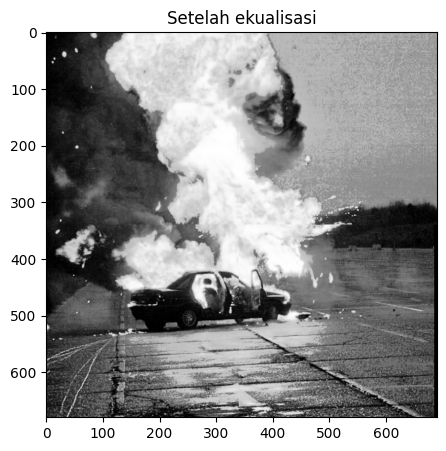

In [106]:
hasilEq = ekualisasi(mobilGray)

tampilkan_citra(hasilEq, "Setelah ekualisasi")

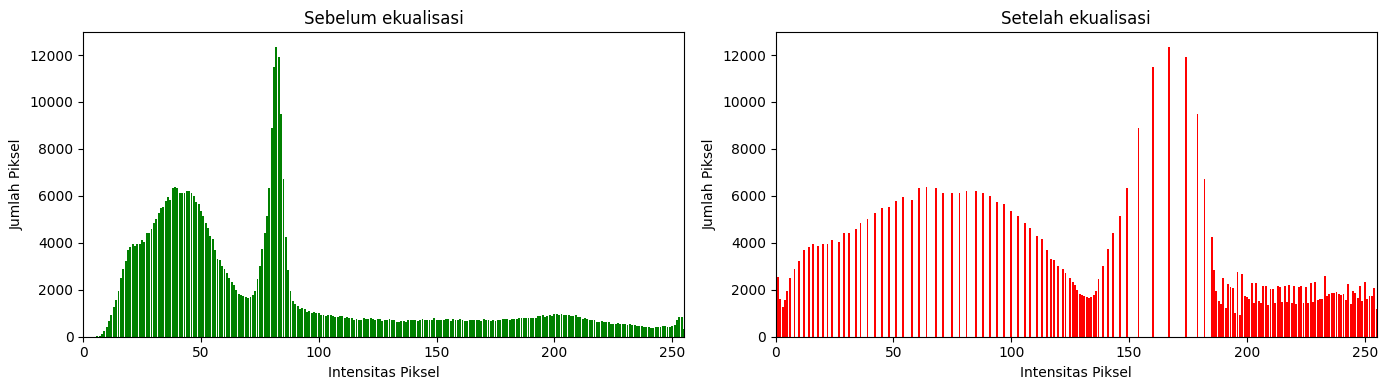

In [107]:
bandingkan_histogram(mobilGray, hasilEq, "Sebelum ekualisasi", "Setelah ekualisasi")

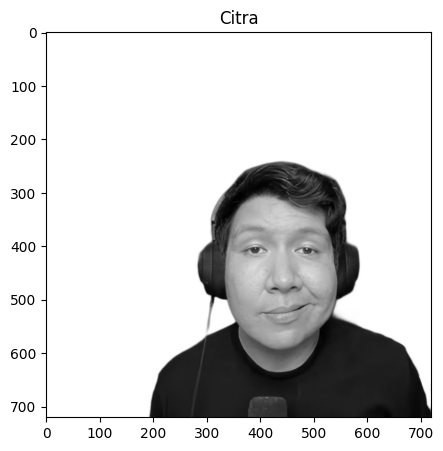

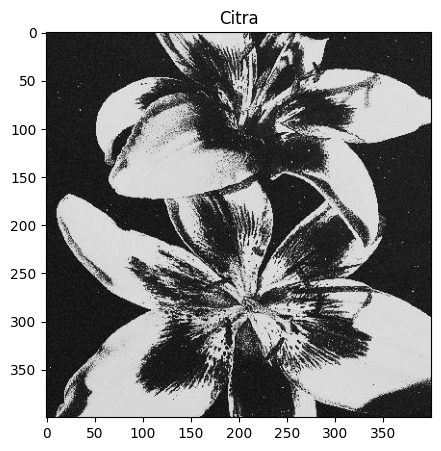

In [108]:
windut = baca_grayscale('Assets/Windut.png')
bunga = baca_grayscale('Assets/Bunga.png')

tampilkan_citra(windut)
tampilkan_citra(bunga)

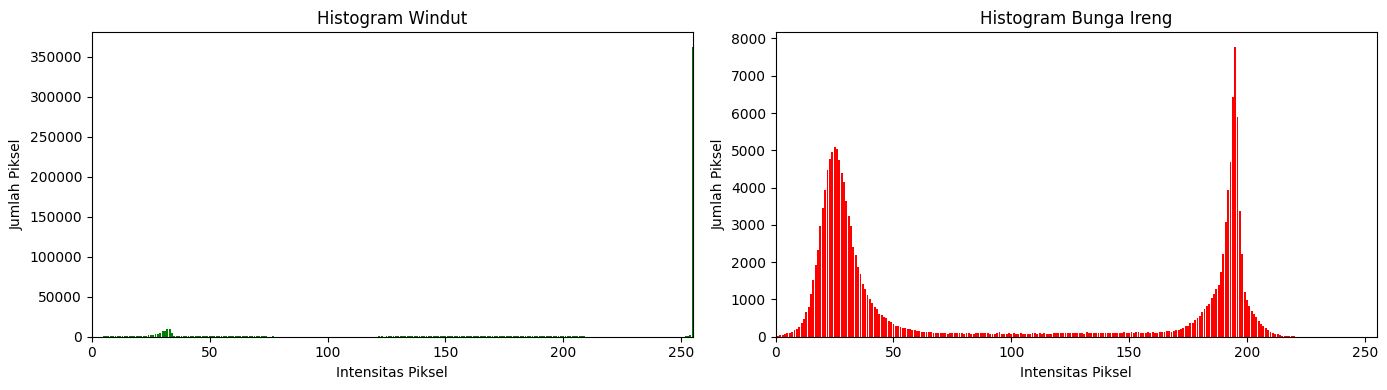

In [109]:
bandingkan_histogram(windut, bunga, "Histogram Windut", "Histogram Bunga Ireng")

In [110]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    height_a, width_a = citra_asal.shape
    for i in range(height_a):
        for j in range(width_a):
            hist_asal[citra_asal[i, j]] += 1
 
    height_t, width_t = citra_target.shape
    for i in range(height_t):
        for j in range(width_t):
            hist_target[citra_target[i, j]] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
 
    return hasil

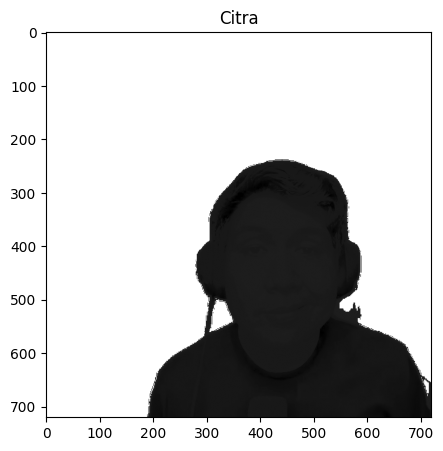

In [111]:
hasilSpes = spesifikasi_histogram(windut, bunga)

tampilkan_citra(hasilSpes)

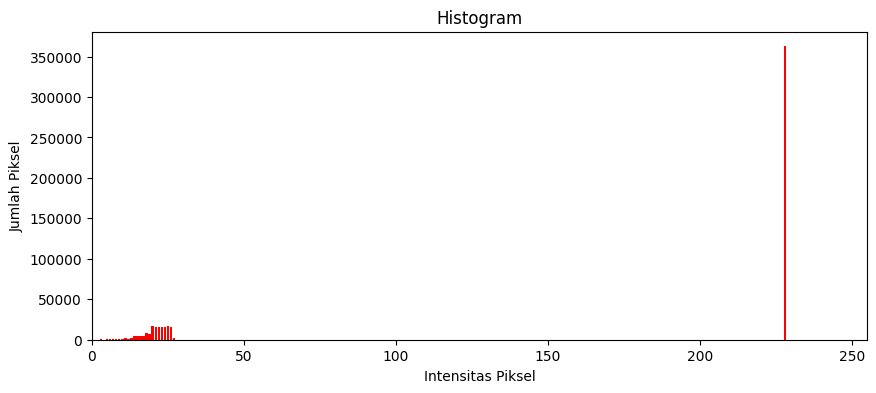

In [112]:
histoSpes = buat_hist(hasilSpes)
histoWarna = plot_histogram(histoSpes)

In [113]:
def buat_mask_threshold(citra, threshold=50, mode="lebih_besar"):
    """
    Membuat mask berdasarkan nilai threshold.

    mode="lebih_besar": piksel > threshold menjadi True
    mode="lebih_kecil": piksel < threshold menjadi True
    """
    citra = pastikan_uint8(citra)

    if mode == "lebih_besar":
        return citra > threshold

    if mode == "lebih_kecil":
        return citra < threshold

    raise ValueError("mode harus 'lebih_besar' atau 'lebih_kecil'.")


def terapkan_mask(citra_asal, citra_pengganti, mask):
    """
    Mengganti area citra_asal dengan citra_pengganti berdasarkan mask.
    """
    if citra_asal.shape != citra_pengganti.shape:
        citra_pengganti = cv.resize(
            citra_pengganti,
            (citra_asal.shape[1], citra_asal.shape[0]),
            interpolation=cv.INTER_AREA
        )

    hasil = np.copy(citra_asal)
    hasil[mask] = citra_pengganti[mask]

    return hasil


def ganti_latar_threshold(citra_asal, citra_latar, threshold=50, mode="lebih_besar"):
    mask = buat_mask_threshold(citra_asal, threshold=threshold, mode=mode)
    hasil = terapkan_mask(citra_asal, citra_latar, mask)
    return hasil, mask


In [ ]:
tinggi = min(hasilSpes.shape[0], hasilEq.shape[0])
lebar = min(hasilSpes.shape[1], hasilEq.shape[1])

hasilSpes_crop = hasilSpes[:tinggi, :lebar]
hasilEq_crop = hasilEq[:tinggi, :lebar]

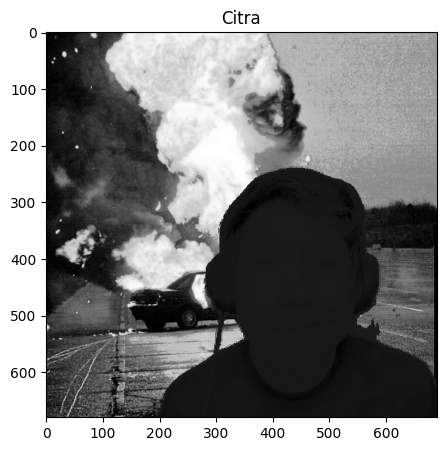

In [117]:
tinggi = min(hasilSpes.shape[0], hasilEq.shape[0])
lebar = min(hasilSpes.shape[1], hasilEq.shape[1])

hasilSpes_crop = hasilSpes[0:tinggi, 0:lebar]
hasilEq_crop = hasilEq[0:tinggi, 0:lebar]

mask = buat_mask_threshold(hasilSpes_crop,threshold=100,mode="lebih_kecil")
hasil_akhir1 = terapkan_mask(hasilEq_crop,hasilSpes_crop,mask)
tampilkan_citra(hasil_akhir1)

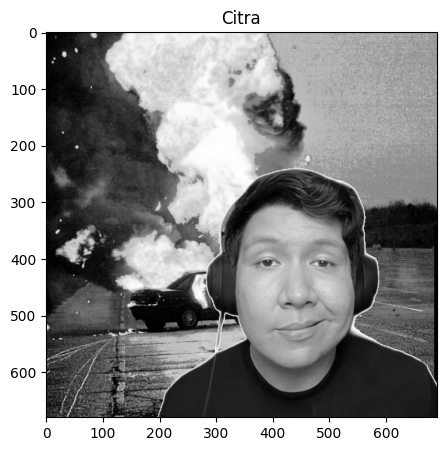

In [119]:
tinggi = min(windut.shape[0], hasilEq.shape[0])
lebar = min(windut.shape[1], hasilEq.shape[1])

windut_crop = windut[0:tinggi, 0:lebar]
hasilEq_crop = hasilEq[0:tinggi, 0:lebar]

mask = buat_mask_threshold(windut_crop, threshold=250, mode="lebih_kecil")
adaWindut= terapkan_mask(hasilEq_crop, windut_crop, mask)
tampilkan_citra(adaWindut)

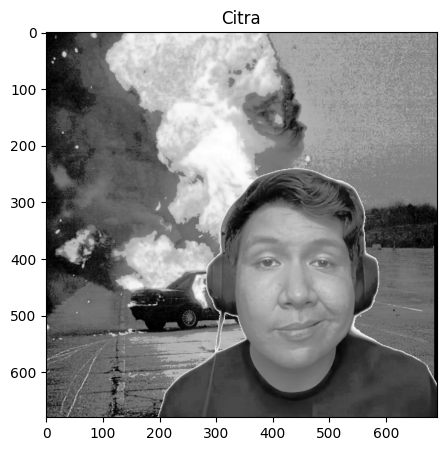

In [120]:
langit = baca_grayscale('Assets/Langit.png')
hasilSpesWindut = spesifikasi_histogram(adaWindut, langit)

tampilkan_citra(hasilSpesWindut)